<a href="https://colab.research.google.com/github/iztzx/introdatascience/blob/main/GA2_Data_Modelling_Leow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# GA2 DATA MODELLING - FLOOD RISK PREDICTION
# Leow Shen En
# ============================================================

# 1. Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay
)

In [ ]:
# ============================================================
# 2. Load dataset
# ============================================================
df = pd.read_csv("Final_Merged_All.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (564600, 25)


,Date_Time,Year,Month,State_Code,State_Name,District_Code,District_Name,Place,Temperature,Pressure,...,UV_Index,Feel_Like_Temp,Visibility,Solar_Radiation,Pollutant_Value,Precipitation_Rate,Precipitation_Total,Monthly_Rainfall_Current_Month,Annual_Rainfall,Flood
0,2005-10-01 11:00:00,2005,10,111,Selangor,111006,Kuala Selangor,Bandar Baru Kuala Selangor,27.63271,1009.64,...,0.0,30.608398,9.0,0.0,60.0,0.0,0.0,294.11,2631.0,0.0
1,2005-10-01 17:00:00,2005,10,111,Selangor,111006,Kuala Selangor,Bandar Baru Kuala Selangor,27.63271,1009.64,...,0.0,30.608398,9.0,0.0,59.0,0.0,0.0,294.11,2631.0,0.0
2,2005-10-02 11:00:00,2005,10,111,Selangor,111006,Kuala Selangor,Bandar Baru Kuala Selangor,27.63271,1009.64,...,0.0,30.608398,9.0,0.0,50.0,0.0,0.0,294.11,2631.0,0.0
3,2005-10-02 17:00:00,2005,10,111,Selangor,111006,Kuala Selangor,Bandar Baru Kuala Selangor,27.63271,1009.64,...,0.0,30.608398,9.0,0.0,51.0,0.0,0.0,294.11,2631.0,0.0
4,2005-10-03 11:00:00,2005,10,111,Selangor,111006,Kuala Selangor,Bandar Baru Kuala Selangor,27.63271,1009.64,...,0.0,30.608398,9.0,0.0,52.0,0.0,0.0,294.11,2631.0,0.0


In [ ]:
# ============================================================
# 3. Check columns
# ============================================================

print("Columns in dataset:")
for col in df.columns:
    print(col)

Columns in dataset:
Date_Time
Year
Month
State_Code
State_Name
District_Code
District_Name
Place
Temperature
Pressure
Dew_Point
Humidity
Wind_Speed
Gust
Wind_Chill
UV_Index
Feel_Like_Temp
Visibility
Solar_Radiation
Pollutant_Value
Precipitation_Rate
Precipitation_Total
Monthly_Rainfall_Current_Month
Annual_Rainfall
Flood


In [ ]:
# ============================================================
# 4. Check target variable
# ============================================================

print("Flood target distribution:")
print(df["Flood"].value_counts())

Flood target distribution:
Flood
0.0    330587
1.0    234012
Name: count, dtype: int64


In [ ]:
# ============================================================
# 5. Check missing values
# ============================================================

print("Missing values before cleaning:")
print(df.isnull().sum())

Missing values before cleaning:
Date_Time                         0
Year                              0
Month                             0
State_Code                        0
State_Name                        0
District_Code                     0
District_Name                     0
Place                             0
Temperature                       0
Pressure                          0
Dew_Point                         0
Humidity                          0
Wind_Speed                        0
Gust                              0
Wind_Chill                        0
UV_Index                          1
Feel_Like_Temp                    1
Visibility                        1
Solar_Radiation                   1
Pollutant_Value                   1
Precipitation_Rate                1
Precipitation_Total               1
Monthly_Rainfall_Current_Month    1
Annual_Rainfall                   1
Flood                             1
dtype: int64


In [ ]:
# ============================================================
# 6. Clean missing values and target variable
# ============================================================

df = df.dropna()
df["Flood"] = df["Flood"].astype(int)

print("Dataset shape after dropping missing values:", df.shape)
print("Flood distribution after cleaning:")
print(df["Flood"].value_counts())

Dataset shape after dropping missing values: (564599, 25)
Flood distribution after cleaning:
Flood
0    330587
1    234012
Name: count, dtype: int64


In [ ]:
# ============================================================
# 7. Define safer feature columns
# ============================================================
# Removed possible leakage features:
# - Annual_Rainfall
# - Monthly_Rainfall_Current_Month
# - Year
#
# Reason:
# Annual_Rainfall and Monthly_Rainfall_Current_Month may contain
# post-event rainfall summaries.
# Year may allow the model to memorize historical patterns.

feature_cols = [
    "Month",
    "State_Code",
    "District_Code",
    "Temperature",
    "Pressure",
    "Dew_Point",
    "Humidity",
    "Wind_Speed",
    "Gust",
    "Wind_Chill",
    "UV_Index",
    "Feel_Like_Temp",
    "Visibility",
    "Solar_Radiation",
    "Pollutant_Value",
    "Precipitation_Rate",
    "Precipitation_Total"
]

target_col = "Flood"

print("Number of selected features:", len(feature_cols))
print("Selected features:")
for col in feature_cols:
    print(col)

Number of selected features: 17
Selected features:
Month
State_Code
District_Code
Temperature
Pressure
Dew_Point
Humidity
Wind_Speed
Gust
Wind_Chill
UV_Index
Feel_Like_Temp
Visibility
Solar_Radiation
Pollutant_Value
Precipitation_Rate
Precipitation_Total


In [ ]:
# ============================================================
# 8. Time-based train-test split
# ============================================================
# Instead of random split, use earlier years for training
# and later years for testing.

df = df.sort_values(by=["Year", "Month"])

print("Year range in dataset:")
print(df["Year"].min(), "-", df["Year"].max())

train_df = df[df["Year"] <= 2008]
test_df = df[df["Year"] > 2008]

X_train = train_df[feature_cols]
y_train = train_df[target_col]

X_test = test_df[feature_cols]
y_test = test_df[target_col]

print("Training years:", train_df["Year"].min(), "-", train_df["Year"].max())
print("Testing years:", test_df["Year"].min(), "-", test_df["Year"].max())

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Year range in dataset:
2000 - 2010
Training years: 2000 - 2008
Testing years: 2009 - 2010
X_train: (449062, 17)
X_test: (115537, 17)

Training target distribution:
Flood
0    254505
1    194557
Name: count, dtype: int64

Testing target distribution:
Flood
0    76082
1    39455
Name: count, dtype: int64


In [ ]:
# ============================================================
# 9. Baseline model
# ============================================================
# Baseline model predicts the majority class.
# This helps us check whether ML models perform better than a simple rule.

baseline_model = DummyClassifier(strategy="most_frequent")
baseline_model.fit(X_train, y_train)

baseline_pred = baseline_model.predict(X_test)

print("Baseline Model Results:")
print(classification_report(y_test, baseline_pred, zero_division=0))

Baseline Model Results:
              precision    recall  f1-score   support

           0       0.66      1.00      0.79     76082
           1       0.00      0.00      0.00     39455

    accuracy                           0.66    115537
   macro avg       0.33      0.50      0.40    115537
weighted avg       0.43      0.66      0.52    115537



In [ ]:
# ============================================================
# 10. Logistic Regression with scaling
# ============================================================

log_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=3000)
)

log_model.fit(X_train, y_train)
log_pred = log_model.predict(X_test)

print("Logistic Regression Results:")
print(classification_report(y_test, log_pred))

Logistic Regression Results:
              precision    recall  f1-score   support

           0       0.73      0.68      0.70     76082
           1       0.46      0.53      0.49     39455

    accuracy                           0.63    115537
   macro avg       0.60      0.60      0.60    115537
weighted avg       0.64      0.63      0.63    115537



In [ ]:
# ============================================================
# 11. Decision Tree
# ============================================================

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

print("Decision Tree Results:")
print(classification_report(y_test, dt_pred))

Decision Tree Results:
              precision    recall  f1-score   support

           0       0.74      0.65      0.69     76082
           1       0.46      0.57      0.51     39455

    accuracy                           0.62    115537
   macro avg       0.60      0.61      0.60    115537
weighted avg       0.65      0.62      0.63    115537



In [ ]:
# ============================================================
# 12. Random Forest
# ============================================================

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("Random Forest Results:")
print(classification_report(y_test, rf_pred))

Random Forest Results:
              precision    recall  f1-score   support

           0       0.81      0.56      0.66     76082
           1       0.47      0.75      0.58     39455

    accuracy                           0.63    115537
   macro avg       0.64      0.66      0.62    115537
weighted avg       0.70      0.63      0.63    115537



In [ ]:
# ============================================================
# 13. Limited Decision Tree
# ============================================================

dt_model_limited = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt_model_limited.fit(X_train, y_train)
dt_limited_pred = dt_model_limited.predict(X_test)

print("Limited Decision Tree Results:")
print(classification_report(y_test, dt_limited_pred))

Limited Decision Tree Results:
              precision    recall  f1-score   support

           0       0.89      0.50      0.64     76082
           1       0.48      0.88      0.62     39455

    accuracy                           0.63    115537
   macro avg       0.69      0.69      0.63    115537
weighted avg       0.75      0.63      0.64    115537



In [ ]:
# ============================================================
# 14. Compare train and test accuracy
# ============================================================
# This helps detect possible overfitting.

print("Decision Tree training accuracy:", dt_model.score(X_train, y_train))
print("Decision Tree testing accuracy:", dt_model.score(X_test, y_test))

print("Random Forest training accuracy:", rf_model.score(X_train, y_train))
print("Random Forest testing accuracy:", rf_model.score(X_test, y_test))

print("Limited Decision Tree training accuracy:", dt_model_limited.score(X_train, y_train))
print("Limited Decision Tree testing accuracy:", dt_model_limited.score(X_test, y_test))

Decision Tree training accuracy: 0.7290396426328658
Decision Tree testing accuracy: 0.6230817833248223
Random Forest training accuracy: 0.7290374157688694
Random Forest testing accuracy: 0.6250378666574344
Limited Decision Tree training accuracy: 0.6941535912635671
Limited Decision Tree testing accuracy: 0.6329833732916728


In [ ]:
# ============================================================
# 15. Model comparison table
# ============================================================

models = {
    "Baseline": baseline_pred,
    "Logistic Regression": log_pred,
    "Decision Tree": dt_pred,
    "Random Forest": rf_pred,
    "Limited Decision Tree": dt_limited_pred
}

results = []

for name, pred in models.items():
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1-score": f1_score(y_test, pred, zero_division=0)
    })

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1-score
0,Baseline,0.658508,0.000000,0.000000,0.000000
1,Logistic Regression,0.626128,0.458730,0.526955,0.490481
2,Decision Tree,0.623082,0.458227,0.568977,0.507632
3,Random Forest,0.625038,0.469494,0.754201,0.578727
4,Limited Decision Tree,0.632983,0.479706,0.883386,0.621771


In [ ]:
# ============================================================
# 16. Save model comparison table as CSV
# ============================================================

results_df.to_csv("model_comparison_results_after_leakage_fix.csv", index=False)

print("Saved: model_comparison_results_after_leakage_fix.csv")

Saved: model_comparison_results_after_leakage_fix.csv


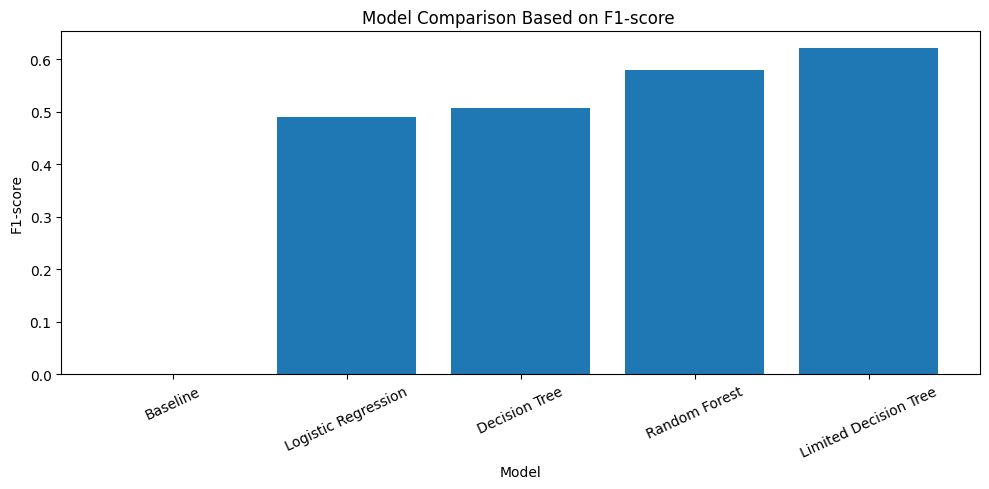

In [ ]:
# ============================================================
# 17. F1-score comparison chart
# ============================================================

plt.figure(figsize=(10, 5))
plt.bar(results_df["Model"], results_df["F1-score"])
plt.xlabel("Model")
plt.ylabel("F1-score")
plt.title("Model Comparison Based on F1-score ")
plt.xticks(rotation=25)
plt.tight_layout()
plt.savefig("model_comparison_f1_after_leakage_fix.png", dpi=300, bbox_inches="tight")
plt.show()

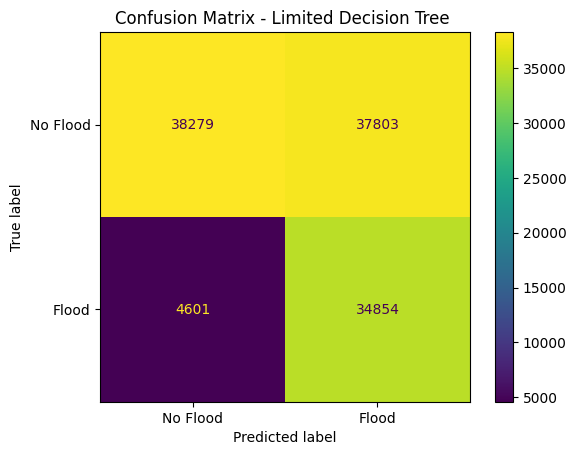

In [ ]:
# ============================================================
# 18. Confusion matrix
# ============================================================
# Use the Limited Decision Tree for interpretation.

cm = confusion_matrix(y_test, dt_limited_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Flood", "Flood"]
)

disp.plot()
plt.title("Confusion Matrix - Limited Decision Tree ")
plt.savefig("confusion_matrix_limited_dt_after_leakage_fix.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# ============================================================
# 19. Feature importance
# ============================================================

importance_df = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": dt_model_limited.feature_importances_
})

importance_df = importance_df.sort_values(by="Importance", ascending=False)

importance_df

,Feature,Importance
1,State_Code,0.520779
2,District_Code,0.415645
5,Dew_Point,0.022642
7,Wind_Speed,0.017293
0,Month,0.011680
4,Pressure,0.004364
6,Humidity,0.003632
12,Visibility,0.002175
14,Pollutant_Value,0.000909
11,Feel_Like_Temp,0.000880


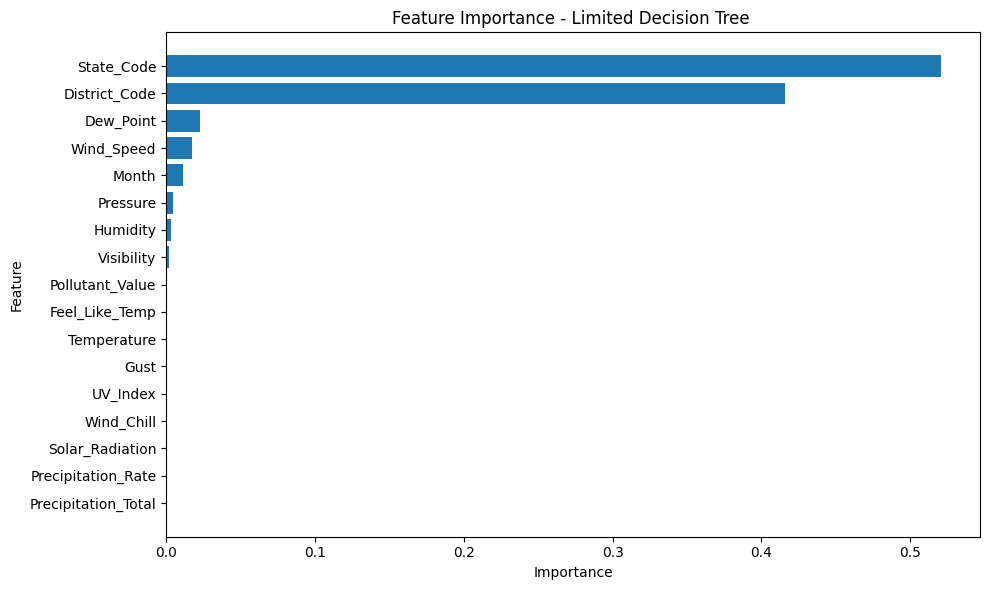

In [ ]:
# ============================================================
# 20. Feature importance chart
# ============================================================

plt.figure(figsize=(10, 6))
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance - Limited Decision Tree ")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("feature_importance_limited_dt_after_leakage_fix.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# ============================================================
# 21. ROC/AUC analysis
# ============================================================
# AUC measures how well the model separates flood and non-flood classes.

# Logistic Regression probability
log_proba = log_model.predict_proba(X_test)[:, 1]

# Decision Tree probability
dt_proba = dt_model.predict_proba(X_test)[:, 1]

# Random Forest probability
rf_proba = rf_model.predict_proba(X_test)[:, 1]

# Limited Decision Tree probability
dt_limited_proba = dt_model_limited.predict_proba(X_test)[:, 1]

auc_results = {
    "Logistic Regression": roc_auc_score(y_test, log_proba),
    "Decision Tree": roc_auc_score(y_test, dt_proba),
    "Random Forest": roc_auc_score(y_test, rf_proba),
    "Limited Decision Tree": roc_auc_score(y_test, dt_limited_proba)
}

auc_df = pd.DataFrame(list(auc_results.items()), columns=["Model", "ROC-AUC"])
auc_df

,Model,ROC-AUC
0,Logistic Regression,0.672060
1,Decision Tree,0.671589
2,Random Forest,0.683622
3,Limited Decision Tree,0.696373


<Figure size 800x600 with 0 Axes>

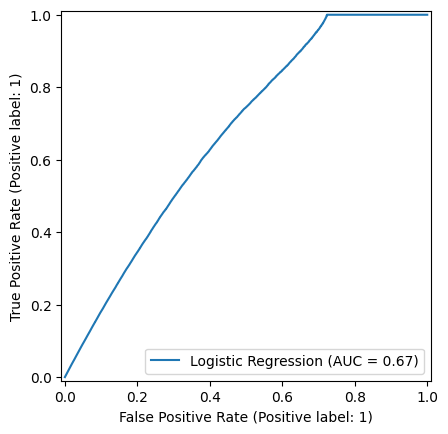

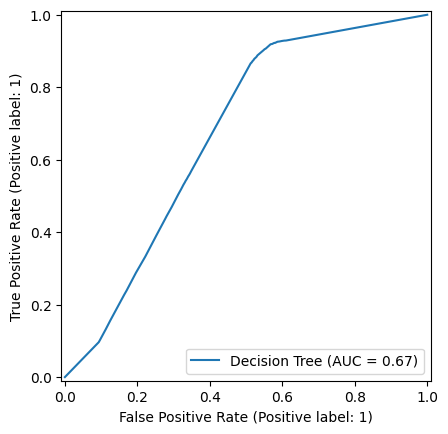

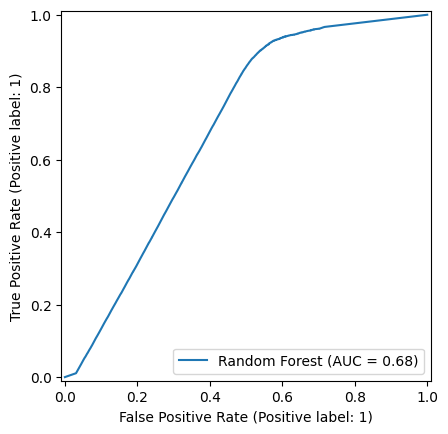

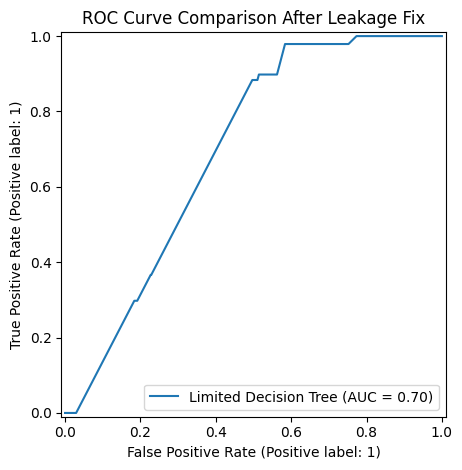

In [ ]:
# ============================================================
# 22. ROC curve
# ============================================================

plt.figure(figsize=(8, 6))

RocCurveDisplay.from_predictions(y_test, log_proba, name="Logistic Regression")
RocCurveDisplay.from_predictions(y_test, dt_proba, name="Decision Tree")
RocCurveDisplay.from_predictions(y_test, rf_proba, name="Random Forest")
RocCurveDisplay.from_predictions(y_test, dt_limited_proba, name="Limited Decision Tree")

plt.title("ROC Curve Comparison After Leakage Fix")
plt.tight_layout()
plt.savefig("roc_curve_after_leakage_fix.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# ============================================================
# 23. Optional: one-hot encoding version
# ============================================================
# This fixes the issue where State_Code and District_Code are treated as numbers.
# Run this only if your leader asks for one-hot encoding.

categorical_cols = ["State_Code", "District_Code"]
numeric_cols = [
    "Month",
    "Temperature",
    "Pressure",
    "Dew_Point",
    "Humidity",
    "Wind_Speed",
    "Gust",
    "Wind_Chill",
    "UV_Index",
    "Feel_Like_Temp",
    "Visibility",
    "Solar_Radiation",
    "Pollutant_Value",
    "Precipitation_Rate",
    "Precipitation_Total"
]

X_train_encoded = pd.get_dummies(train_df[categorical_cols + numeric_cols], columns=categorical_cols)
X_test_encoded = pd.get_dummies(test_df[categorical_cols + numeric_cols], columns=categorical_cols)

# Align train and test columns
X_train_encoded, X_test_encoded = X_train_encoded.align(
    X_test_encoded,
    join="left",
    axis=1,
    fill_value=0
)

print("Encoded X_train:", X_train_encoded.shape)
print("Encoded X_test:", X_test_encoded.shape)

Encoded X_train: (449062, 30)
Encoded X_test: (115537, 30)


In [ ]:
# ============================================================
# 24. Optional: Random Forest with one-hot encoded location
# ============================================================

rf_encoded = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_encoded.fit(X_train_encoded, y_train)
rf_encoded_pred = rf_encoded.predict(X_test_encoded)

print("Random Forest with One-Hot Encoding Results:")
print(classification_report(y_test, rf_encoded_pred))

Random Forest with One-Hot Encoding Results:
              precision    recall  f1-score   support

           0       0.81      0.56      0.66     76082
           1       0.47      0.75      0.58     39455

    accuracy                           0.63    115537
   macro avg       0.64      0.66      0.62    115537
weighted avg       0.70      0.63      0.63    115537

